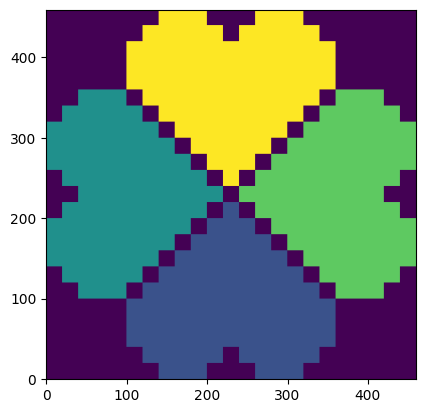

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, transform

image = np.zeros((2*230, 2*230))
heart = np.zeros((2*130, 2*110))
segment = np.zeros((2*70, 2*110))

segment[2*0:2*10, 2*60:2*90] = 1
segment[2*10:2*20, 2*50:2*100] = 1
segment[2*20:2*30, 2*40:2*110] = 1
segment[2*30:2*40, 2*30:2*110] = 1
segment[2*40:2*50, 2*20:2*110] = 1
segment[2*50:2*60, 2*10:2*100] = 1
segment[2*60:2*70, 2*0:2*90] = 1

heart[:2*70, :2*110] = segment.copy()
heart[2*60:2*130, :2*110] = segment.copy()[::-1, :]

image[2*50:2*180, -2*110:] = heart.copy()
image[2*50:2*180, :2*110] = heart.copy()[:, ::-1]
# image[20:130, -180:-50] = heart.copy().T[::-1]
# image[:-180]

inds = np.where(image > 0)

image[inds[1], inds[0]] = 1

labeled = measure.label(image > 0, connectivity=1)

plt.imshow(labeled, origin="lower")
plt.show()

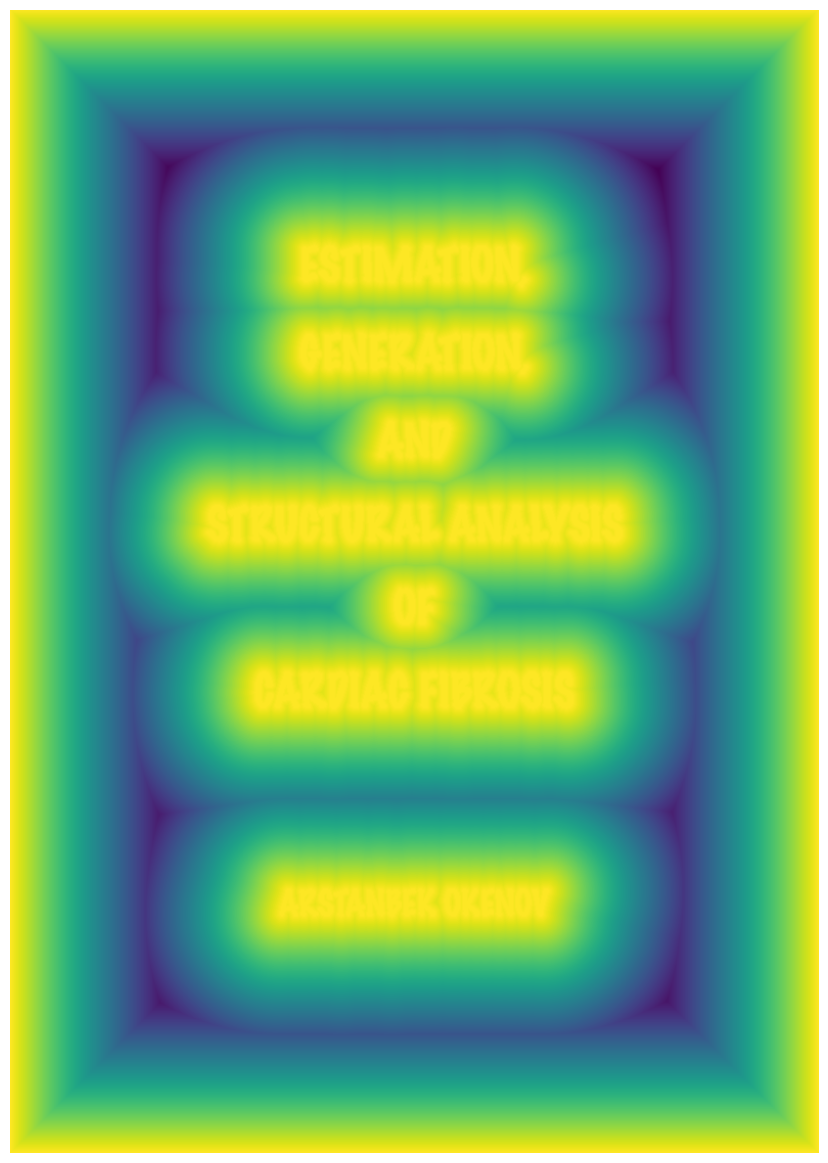

In [109]:
# load png as gray
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, morphology


image = io.imread("/Users/arstanbek/Projects/fibrosis/BiTis/Tutorials/base.png",
                  as_gray=True)
image_or = image < 0.5
image = image_or.copy()
image[-1, :] = 1
image[:, -1] = 1
image[0, :] = 1
image[:, 0] = 1
# # morphological closing
# for i in range(5):
#     image = morphology.binary_dilation(image, morphology.disk(3))

# calculate distance transform
from scipy.ndimage import distance_transform_edt

distance = distance_transform_edt(image == 0)
# normalize distance
distance = distance / np.max(distance)
# invert distance
distance = 1 - distance
# threshold distance

plt.figure(figsize=(5*2.10, 5*2.97))
plt.imshow(distance, vmin=0, vmax=1)
plt.axis("off")
plt.show()

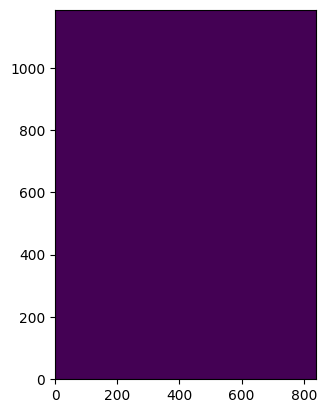

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, transform

image = np.zeros((4*297, 4*210))

for i in range(4):
    image[:, :] = 3
# image[20:130, -180:-50] = heart.copy().T[::-1]
# image[:-180]

labeled = image.copy()
plt.imshow(labeled, origin="lower")
plt.show()

In [240]:
import numpy as np
import matplotlib.pyplot as plt

import bitis as bt

from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

df = bt.tissue_dataset()

# Filter the dataset to extract one specific texture that meets the criteria:
filtered_df = df[(df['Density'].between(0.2, 0.5)) &
                 (df['Elongation'] > 0)]


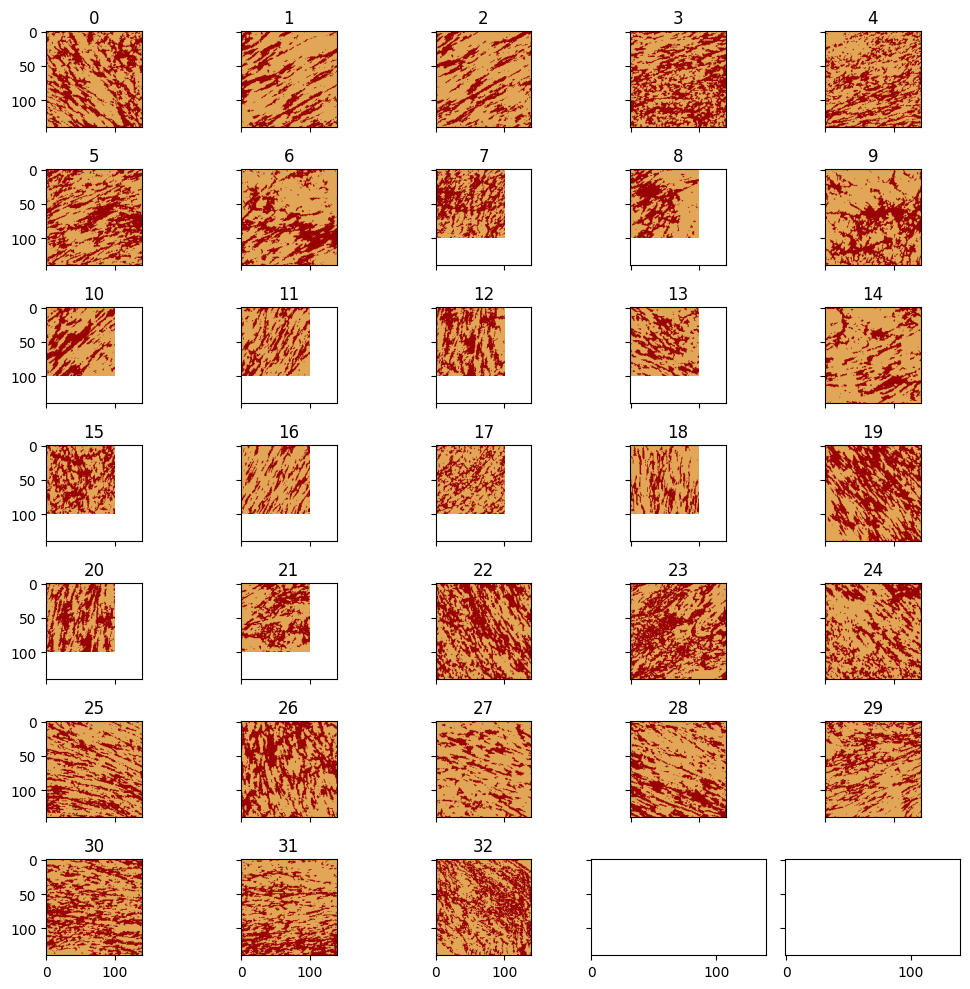

In [7]:
fig, axs = plt.subplots(ncols=5, nrows=int(filtered_df.shape[0] / 5) + 1,
                        sharex=True, sharey=True, figsize=(10, 10))
for i in range(filtered_df.shape[0]):
    ax = axs.flat[i]
    texture = filtered_df["Tissue Matrix"].iloc[i]
    texture = np.where(texture == 0, 1, 2).astype(np.float32)

    ax.imshow(texture, cmap=tex_cmap, vmin=0, vmax=2)
    ax.set_title(i)

plt.tight_layout()
plt.show()

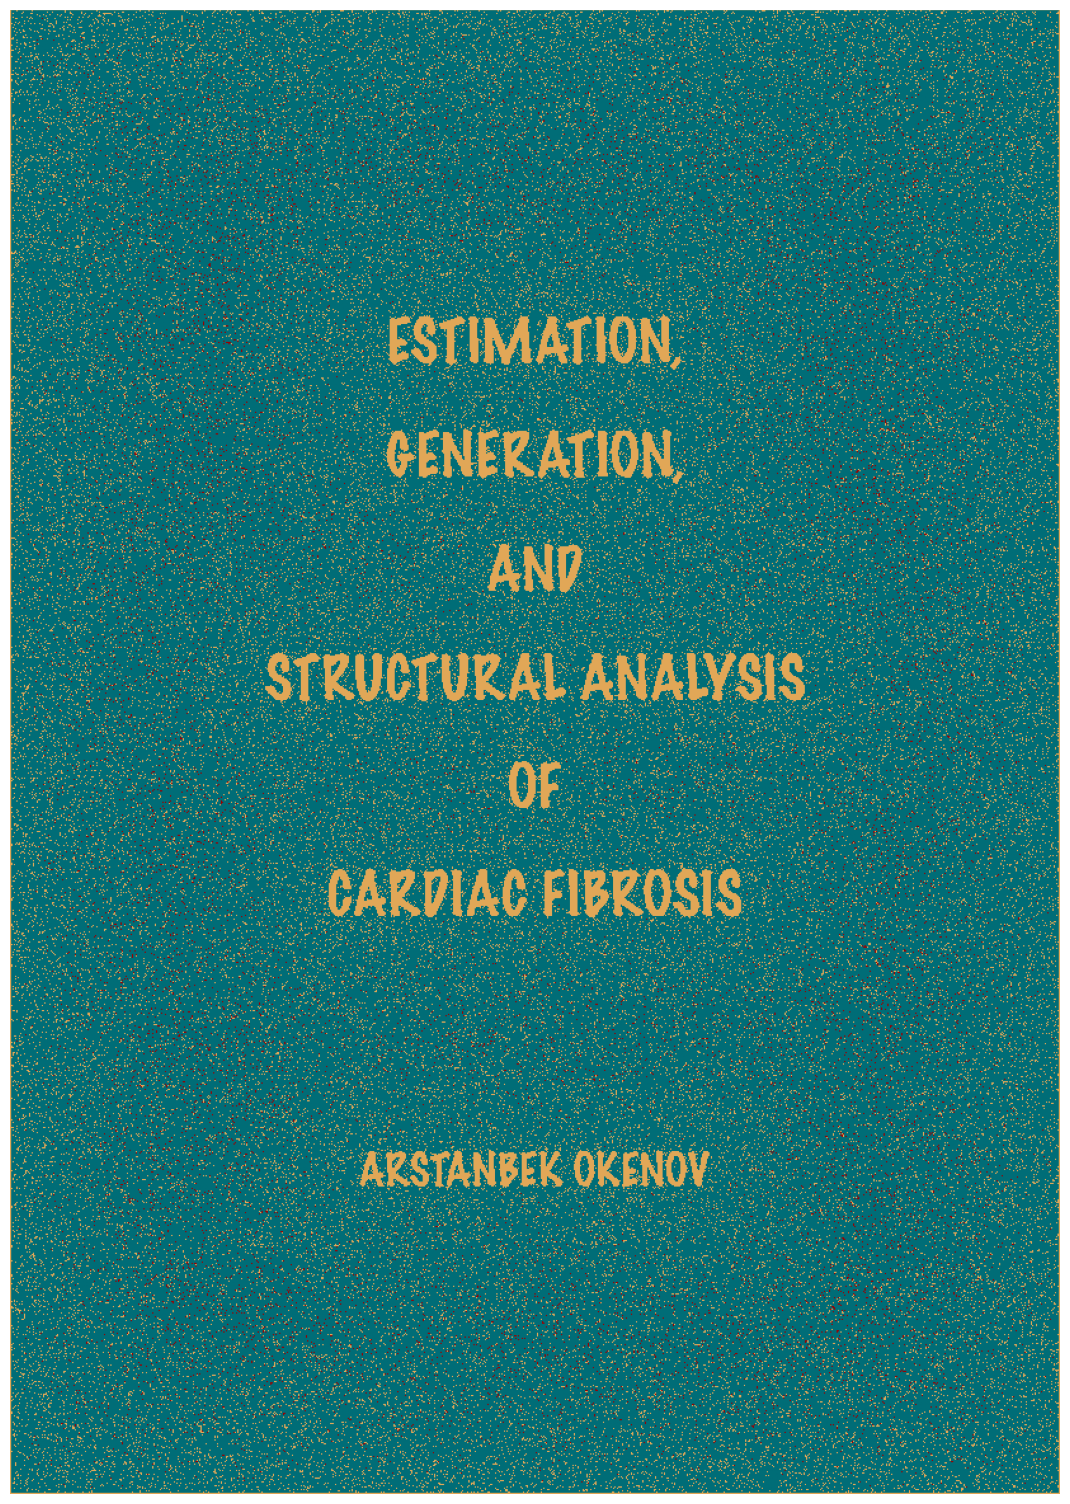

In [113]:

simulation_tex = np.zeros_like(image).astype(np.float32)

random_field = np.random.rand(*image.shape)
simulation_tex[::] = 1
simulation_tex[(random_field < 0.5 * (1 - distance)) & (distance < 0.97)] = 2
simulation_tex[np.random.rand(*image.shape) > 0.1] = 0

simulation_tex[image > 0.5] = 1

plt.figure(figsize=(5*2.10, 5*2.97))
plt.imshow(simulation_tex[::], vmin=0, vmax=2, cmap=tex_cmap)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [111]:
import numpy as np
import matplotlib.pyplot as plt

import bitis as bt

ind = 16

# simulation_tex = np.zeros_like(image).astype(np.float32)
# simulation_tex[image > 0] = 1
simulation_tex[-5:, :] = 1
simulation_tex[:, -5:] = 1
simulation_tex[:5, :] = 1
simulation_tex[:, :5] = 1

texture = filtered_df["Tissue Matrix"].iloc[ind]

# 1 - healthy tissue, 2 - fibrosis
texture = np.where(texture == 0, 1, 2).astype(np.float32)[:100, :100]

training_tex = texture.copy().astype(float)

simulation = bt.AdaptiveSampling(simulation_tex,
                                 training_tex,
                                 max_known_pixels=30,
                                 min_known_pixels=5,
                                 max_template_size=50,
                                 min_template_size=5,
                                 n_candidates=1)
simulation_tex = simulation.run()

100%|██████████| 827164/827164 [01:28<00:00, 9386.51it/s]


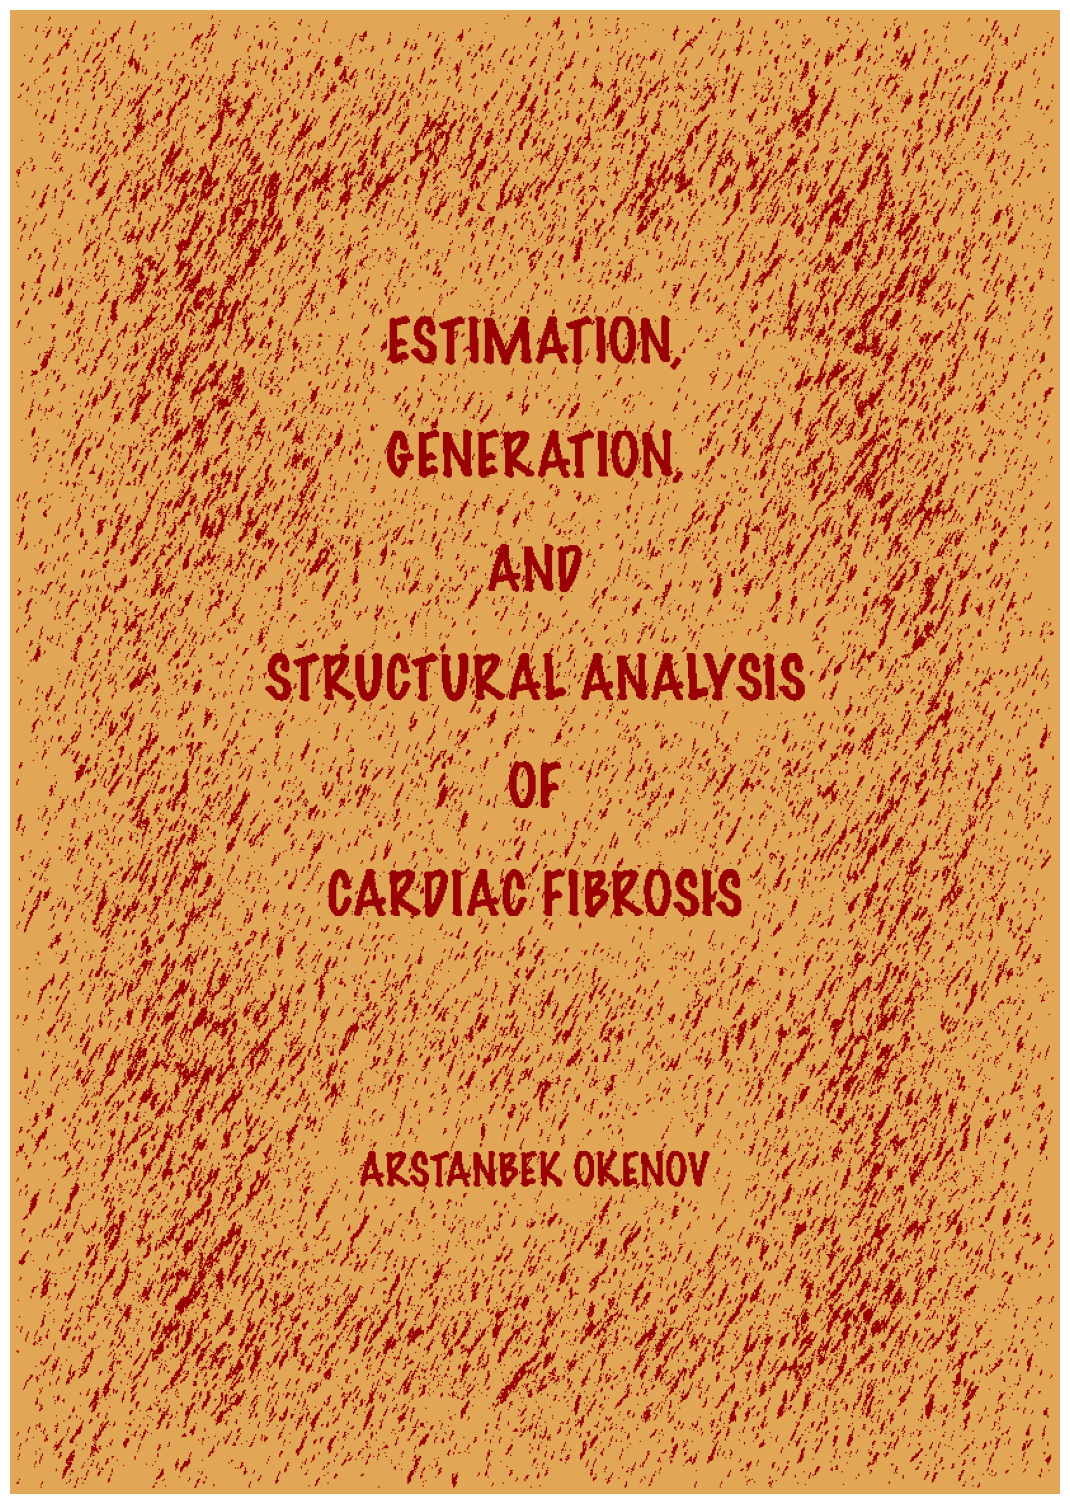

In [112]:

from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, '#006d77'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

# tex_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'fibrosis', [(0, 'black'),
#                  (0.5, 'white'),
#                  (1, 'black')])

cover = simulation_tex.copy()
cover[image_or == 1] = 2
fig = plt.figure(figsize=(5*2.10, 5*2.97))
plt.imshow(cover, vmin=0, vmax=2, cmap=tex_cmap)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()
fig.savefig('cover.png', dpi=300, transparent=True,
            bbox_inches='tight', pad_inches=0)

[0.1305  0.2175  0.27475 0.41875 0.58575 0.7155  0.814  ]
[0.174, 0.232, 0.289, 0.462, 0.627, 0.745, 0.837, 0.9]
[0.2175  0.2465  0.30325 0.50525 0.66825 0.7745  0.86   ]


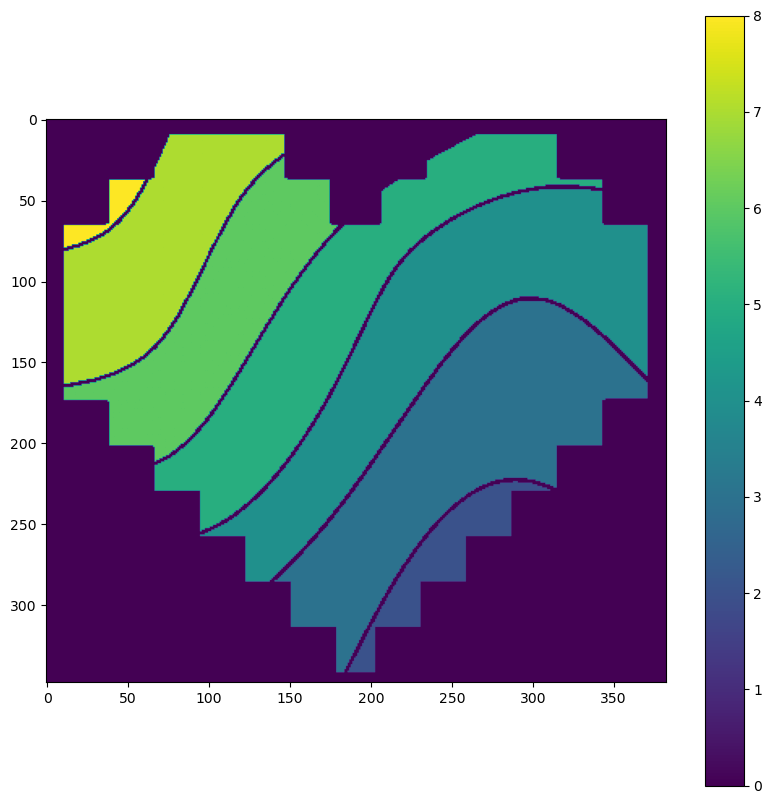

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from skimage import measure, morphology


def keep_largest_object(binary_image):
    # Label connected components
    labeled = measure.label(binary_image)
    
    # Compute region properties
    regions = measure.regionprops(labeled)
    
    if not regions:
        return np.zeros_like(binary_image, dtype=bool)
    
    # Find the largest region
    largest_region = max(regions, key=lambda r: r.area)
    
    # Create a mask with only the largest region
    largest_mask = labeled == largest_region.label
    return largest_mask


path = Path("/Users/arstanbek/Downloads/finitewave-heart.png")
image = plt.imread(path)
image_gr = np.dot(image[..., :3], [0.299, 0.587, 0.114])
image_gr = - (image_gr - 1)
image_gr[image_gr < 0.1] = 0
levels = [0.174, 0.232, 0.289, 0.462, 0.627, 0.745, 0.837, 0.9]
diffs = np.diff([0] + levels)
low_levels = np.array(levels) - diffs / 4
up_levels = np.array(levels) + diffs / 4
low_levels = low_levels[:-1]
up_levels = up_levels[:-1]

print(low_levels)
print(levels)
print(up_levels)

%matplotlib inline

labeled = np.zeros(image_gr.shape, dtype=int)
for i in range(len(up_levels)):
    mask = (image_gr > low_levels[i]) & (image_gr < up_levels[i])
    mask = keep_largest_object(mask)
    labeled[mask] = i + 2

%matplotlib inline
plt.figure(figsize=(10, 10))
plt.imshow(labeled, cmap="viridis")
plt.colorbar()
plt.show()


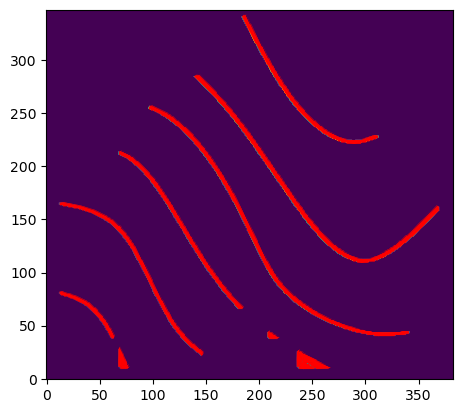

In [20]:
from skimage import graph
from scipy import interpolate


def binary_edges(binary_image):
    # Erode the image
    eroded = morphology.binary_erosion(binary_image)
    # Subtract from original to get the border
    edges = binary_image & ~eroded
    return edges


%matplotlib inline

im = (image_gr > 0).astype(int)

eroded = im.copy()
for i in range(5):
    eroded = morphology.binary_erosion(eroded, footprint=np.ones((3, 3)))
    

outer_edge = binary_edges(image_gr > 0)
between_edges = (eroded + labeled) == 1
between_edges = measure.label(between_edges)

groups = [[1, 4], [3], [2, 5, 7], [6], [8], [9]]

edges_level = np.zeros_like(between_edges)
graphs = []
for i, group in enumerate(groups):
    mask = between_edges == group[0]
    for g in group:
        mask |= between_edges == g

    graph_, nodes = graph.pixel_graph(mask)

    edges_level[mask] = i + 1


edge_coords = np.argwhere(edges_level > 0)

def find_direction(image, coords):
    directions = []
    for coord in coords:
        x_min = max(0, coord[0] - 5)
        x_max = min(image.shape[0], coord[0] + 5)
        y_min = max(0, coord[1] - 5)
        y_max = min(image.shape[1], coord[1] + 5)
        im = image[x_min:x_max, y_min:y_max]
        props = measure.regionprops(im)
        orientation = props[0].orientation
        directions.append(orientation)
    return np.array(directions)

orientations = find_direction((edges_level > 0).astype(int), edge_coords)
dy = 10 * np.cos(orientations + np.pi / 2)
dx = 10 * np.sin(orientations + np.pi / 2)

%matplotlib inline
plt.figure()
plt.imshow(edges_level, origin='lower')
plt.quiver(edge_coords[:, 1], edge_coords[:, 0], dy, dx, color='r', scale_units='xy')
plt.show()


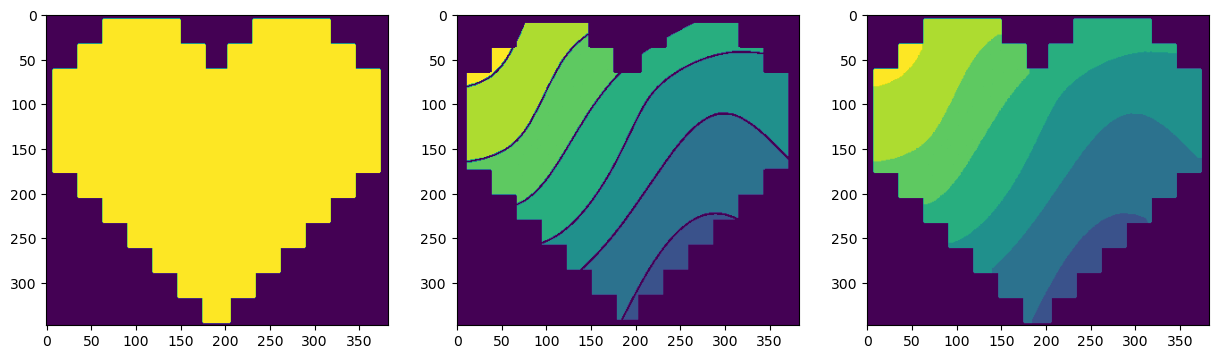

In [21]:
from skimage import morphology


def find_nearest_level(im, levels):
    im_coords = np.argwhere(im > 0)
    levels_coords = np.argwhere(levels > 0)
    idx = find_nearest(im_coords, levels_coords)

    out = np.zeros_like(levels)
    out[im > 0] = levels[tuple(levels_coords[idx].T)]

    return out


levels = find_nearest_level(im, labeled)

%matplotlib inline
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
axs[0].imshow(im)
axs[1].imshow(labeled)
axs[2].imshow(levels)
plt.show()
    
    

In [31]:
from scipy.spatial import KDTree
from scipy import ndimage


def find_nearest(im_coords, coords):
    tree = KDTree(coords)
    _, idx = tree.query(im_coords, k=1)
    return idx

def find_two_nearest(levels, edge_image, orient_map):
    idx_map = {2: [6, 6],
               3: [6, 5],
               4: [5, 4],
               5: [4, 3],
               6: [3, 2],
               7: [2, 1],
               8: [1, 1]}

    dist_maps = [np.zeros_like(levels, dtype=np.float64),
                 np.zeros_like(levels, dtype=np.float64)]
    orient_maps = [np.zeros_like(levels, dtype=np.float64),
                   np.zeros_like(levels, dtype=np.float64)]

    for level, edge_levels in idx_map.items():
        im_coords = np.argwhere(levels == level)
        for i, edge_level in enumerate(edge_levels):
            coords = np.argwhere(edge_image == edge_level)
            tree = KDTree(coords)
            d, idx = tree.query(im_coords, k=1)
            n_coords = coords[idx]
            dist_maps[i][im_coords[:, 0], im_coords[:, 1]] = d
            orient_maps[i][im_coords[:, 0], im_coords[:, 1]] = orient_map[n_coords[:, 0], n_coords[:, 1]]

    return dist_maps, orient_maps


def smooth_mean(image, mask, n=10):
    # Define mean kernel (3x3)
    kernel = np.ones((n, n), dtype=float)

    # Convolve image *with mask*
    masked_image = image * mask
    numerator = ndimage.convolve(masked_image, kernel, mode='constant', cval=0.0)
    denominator = ndimage.convolve(mask.astype(float), kernel, mode='constant', cval=0.0)

    # Avoid division by zero
    denominator[denominator == 0] = 1

    # Mean filtered result (only using masked pixels)
    mean_filtered = numerator / denominator
    return mean_filtered


im = image_gr > 0
im_coords = np.argwhere(im > 0)
nearest_edge_idx = find_nearest(im_coords, edge_coords)

orient_map_ = np.zeros_like(im, dtype=np.float64)
orient_map_[edges_level > 0] = np.where(orientations > 0,
                                        np.pi/2 - orientations,
                                        -np.pi/2 - orientations)

dist_maps, orient_maps = find_two_nearest(levels, edges_level, orient_map_)

dist_maps[0][dist_maps[0] == 0] = 1
dist_maps[1][dist_maps[1] == 0] = 1

dist_maps = [1 - dist_maps[0] / (dist_maps[0] + dist_maps[1]),
             1 - dist_maps[1] / (dist_maps[0] + dist_maps[1])]

# if diff between orient maps is > np.pi/2 then shift values

orient_map = orient_maps[0] * dist_maps[0] + orient_maps[1] * dist_maps[1]
orient_map = orient_map / (dist_maps[0] + dist_maps[1])
# orient_map = smooth_mean(orient_map, im, n=10)

%matplotlib qt
fig, axs = plt.subplots(ncols=2, nrows=3, sharex=True, sharey=True)
for i in range(2):
    axs[0, i].imshow(dist_maps[i], origin='lower')
    axs[1, i].imshow(np.degrees(orient_map), origin='lower')
    axs[2, i].imshow(np.degrees(orient_map_), origin='lower')
plt.show()

    

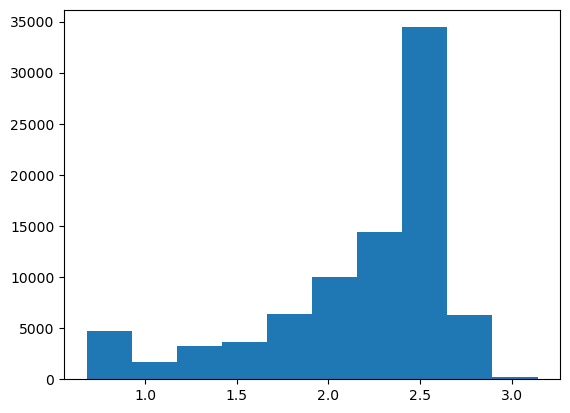

In [38]:
orient = np.where(im_orientations > 0, im_orientations, np.pi + im_orientations)
plt.hist(orient)
plt.show()

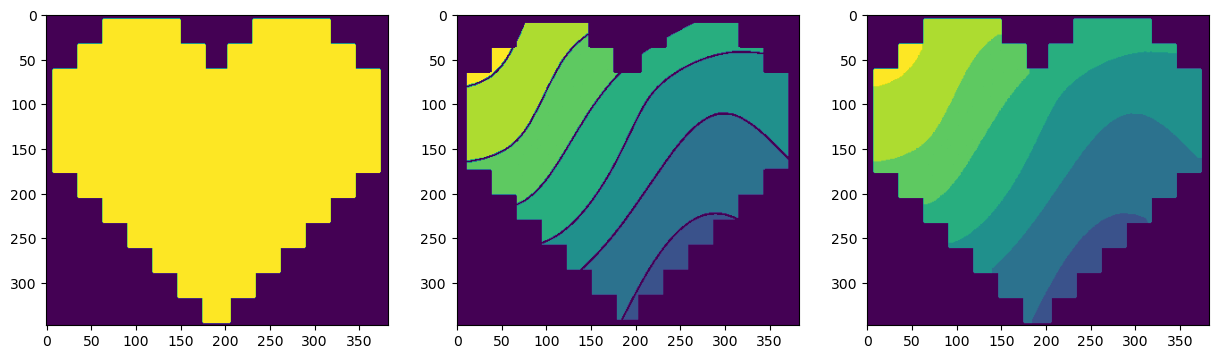

In [19]:
from skimage import morphology


def find_nearest_level(im, levels):
    im_coords = np.argwhere(im > 0)
    levels_coords = np.argwhere(levels > 0)
    idx = find_nearest(im_coords, levels_coords)

    out = np.zeros_like(levels)
    out[im > 0] = levels[tuple(levels_coords[idx].T)]

    return out


levels = find_nearest_level(im, labeled)

%matplotlib inline
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
axs[0].imshow(im)
axs[1].imshow(labeled)
axs[2].imshow(levels)
plt.show()
    
    

(4, 8)


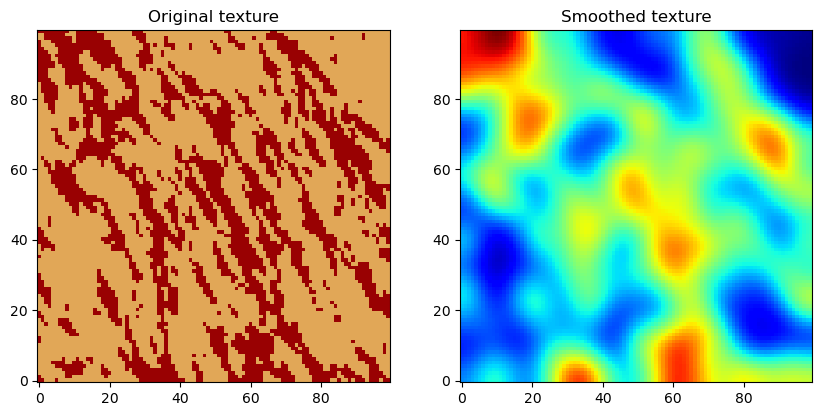

In [69]:
from pathlib import Path
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import bitis as bt

from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

df = bt.tissue_dataset()

# Filter the dataset to extract one specific texture that meets the criteria:
filtered_df = df[(df['Density'].between(0.3, 0.35)) &
                 (df['Elongation'] > 2.5)]

print(filtered_df.shape)
texture = filtered_df["Tissue Matrix"].iloc[1]

# 1 - healthy tissue, 2 - fibrosis
texture = np.where(texture == 0, 1, 2).astype(np.float32)

texture_smoothed = gaussian_filter(texture, sigma=5)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(texture, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
axs[0].set_title('Original texture')
axs[1].imshow(texture_smoothed, cmap='jet', origin='lower')
axs[1].set_title('Smoothed texture')
plt.show()

In [89]:
dens_leves_list = [0.1, 0.3, 0.4, 0.6, 0.4, 0.3, 0.1]

density_map = np.zeros_like(levels, dtype=np.float64)

for i, dens in enumerate(dens_leves_list):
    density_map[levels == i+2] = dens

plt.figure()
plt.imshow(density_map)
plt.show()

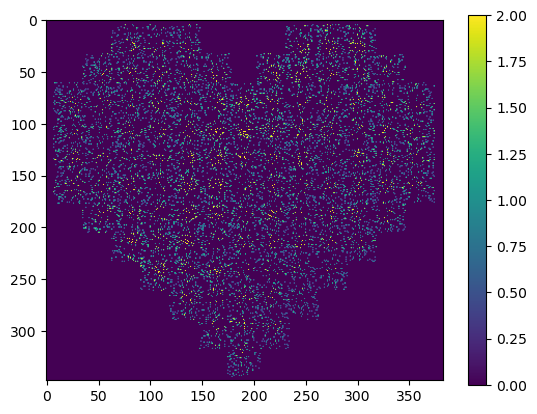

In [90]:
density = np.zeros_like(levels, dtype=np.float64)
# dens_levels = levels[levels > 0]
# dens_levels = (dens_levels - 2) / (dens_levels.max() - 2)
# density[levels > 0] = 1 + ((0.2 + dens_levels * 0.6) > np.random.rand(*dens_levels.shape)).astype(np.float64)

density = 1 + (density_map > np.random.rand(*density_map.shape)).astype(np.float64)
density = density * (np.random.random(density_map.shape) < 0.1)
density[levels == 0] = 0

%matplotlib inline
plt.figure()
plt.imshow(density)
plt.colorbar()
plt.show()

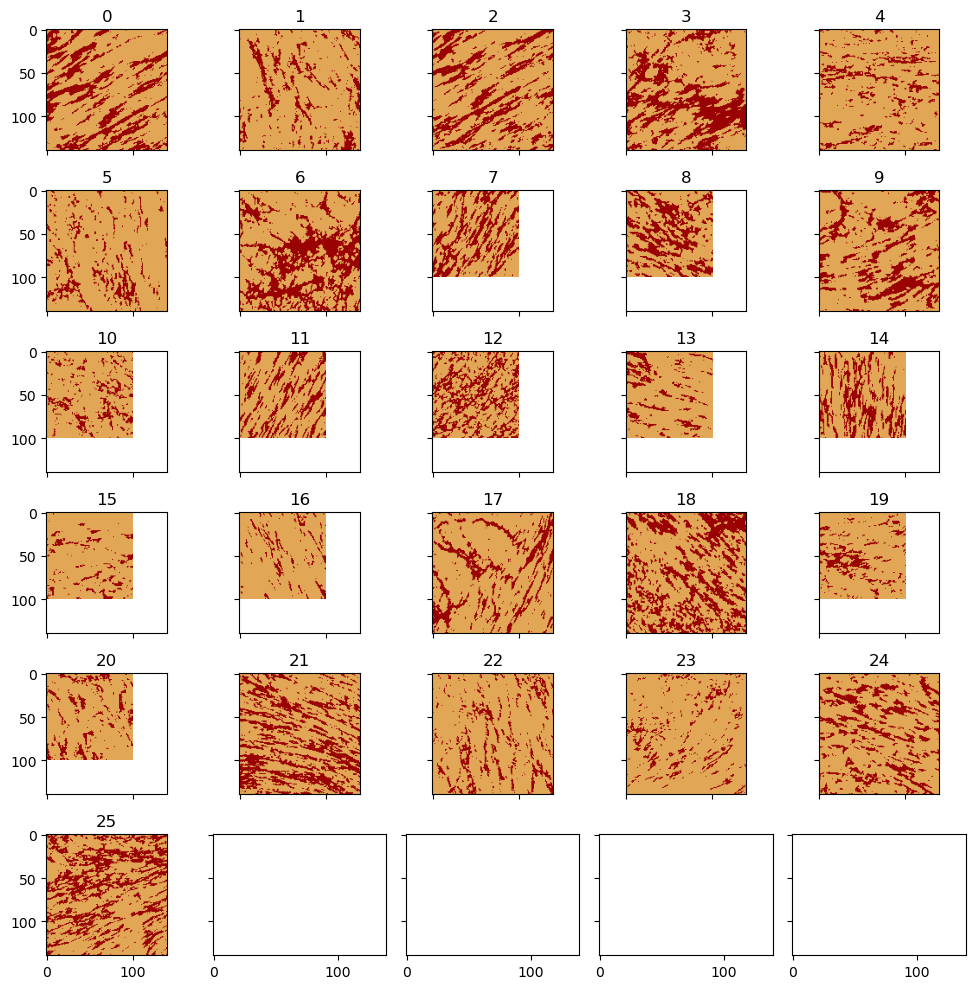

In [ ]:
filtered_df = df[(df['Density'].between(0., 0.35)) &
                 (df['Elongation'] > 1.)]

%matplotlib inline
fig, axs = plt.subplots(ncols=5, nrows=int(filtered_df.shape[0] / 5) + 1,
                        sharex=True, sharey=True, figsize=(10, 10))
for i in range(filtered_df.shape[0]):
    ax = axs.flat[i]
    texture = filtered_df["Tissue Matrix"].iloc[i]
    texture = np.where(texture == 0, 1, 2).astype(np.float32)

    ax.imshow(texture, cmap=tex_cmap, vmin=0, vmax=2)
    ax.set_title(i)

plt.tight_layout()
plt.show()

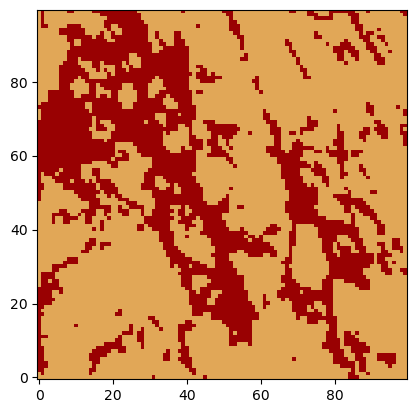

In [ ]:
idx = [3, 6, 11, 12, 16, 22]
i = idx[1]

params = {3: [[50, 150, 50, 150], -40/180],
          6: [[0, 100, -100, None], -45/180],
          
          }

im = filtered_df["Tissue Matrix"].iloc[i]
im = np.where(im == 0, 1, 2).astype(np.float32)
tr_imgs = im[0:100, -100:None]

plt.figure()
plt.imshow(tr_imgs, cmap=tex_cmap, vmin=0, vmax=2, origin='lower')
plt.show()

100%|██████████| 76442/76442 [00:07<00:00, 9764.76it/s]


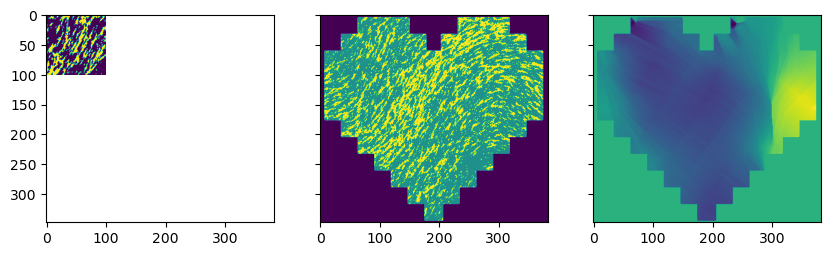

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

import bitis as bt

angle_map = np.degrees(orient_map).astype(np.int64)
tissue_mask = image_gr > 0
training_image = texture

max_known_pixels = 30
max_template_size = 40
min_template_size = 3
num_of_candidates = 1
min_known_pixels = 1

simulation_tex = density.astype(np.float32)
simulation = bt.Simulation()
simulation.path_builder = bt.RandomSimulationPathBuilder(simulation_tex,
                                                         tissue_mask=tissue_mask)
simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
simulation.template_matching = bt.RotatedImagesMatching(training_image,
                                                        angle_map,
                                                        base_angle=-60,
                                                        num_of_candidates=num_of_candidates,
                                                        min_known_pixels=min_known_pixels)
simulated_tex = simulation.run()

%matplotlib inline
fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_image)
ax[1].imshow(simulated_tex)
ax[2].imshow(angle_map)
plt.show()

In [ ]:
%matplotlib qt

out = simulated_tex.copy()
out = np.ma.masked_where(out == 0, out)
# out[edges_level > 0] = 0
fig = plt.figure()
plt.imshow(out, cmap=tex_cmap, vmin=0, vmax=2)
plt.axis('off')
plt.show()

fig.savefig("simulated_tex.png", bbox_inches='tight', pad_inches=0, dpi=300,
            transparent=True, format='png')

: 